# DBSCAN — Density-Based Clustering

**Topic:** Unsupervised Learning — Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from tkh_utils import PALETTE


---
## What you'll explore

By the end of this demo you will be able to:

- **Describe** how DBSCAN classifies points as core, border, and noise using density
- **Explain** how epsilon and min_samples jointly define what counts as a cluster
- **Interpret** DBSCAN output including the -1 noise label and how it differs from k-means output

> **Tip:** In the diagram below, a point's classification (core, border, noise) depends only on how many neighbors sit within its epsilon circle. Try the linked interactive visualizer to drag epsilon and min_samples and watch points flip between core, border, and noise.

---
## How we got here

In **[04_hierarchical_clustering.ipynb](04_hierarchical_clustering.ipynb)** you learned clustering without specifying K. In **[math/linear_algebra/06_norms_and_distances.ipynb](../math/linear_algebra/06_norms_and_distances.ipynb)** you learned how distances are computed. In **[eda/06_outlier_detection.ipynb](../eda/06_outlier_detection.ipynb)** you learned how outliers behave differently from normal data. In **[ml_concepts/11_the_curse_of_dimensionality.ipynb](../ml_concepts/11_the_curse_of_dimensionality.ipynb)** you saw why distance — and therefore density — becomes unreliable in high dimensions; DBSCAN is especially sensitive to this, since its entire decision rule is a distance-based neighbor count.

DBSCAN brings all of these together: it uses density (a neighborhood-based distance criterion) to find clusters of arbitrary shape, and it naturally identifies outliers as points that belong to no dense region.

---
## Why this matters for data science

K-means and GMM both assume clusters are roughly convex. Real-world clusters often aren't: geospatial data forms irregular shapes, customer journeys follow non-linear paths, network communities have complex boundaries.

DBSCAN makes no assumption about cluster shape. It finds any cluster that is dense and connected — crescents, rings, elongated blobs, all work. And unlike k-means, it doesn't force every point into a cluster: low-density points become noise, which is often the right answer for anomaly detection.

\
---
## Where it sits on the spectrum

Referencing **[ml_concepts/13_interpretability_vs_complexity.ipynb](../ml_concepts/13_interpretability_vs_complexity.ipynb)**:

**Interpretability: Medium.** Clusters are regions of density — intuitive in concept, but the epsilon and min_samples parameters require domain knowledge to set meaningfully.

**Complexity: Medium.** With a spatial index (ball tree, k-d tree), O(n log n). Without, O(n²). Memory-efficient compared to hierarchical clustering.

**Position:** Medium interpretability, medium complexity — the best choice when cluster shapes are irregular or when outlier detection is part of the goal.

---
## How it learns

DBSCAN classifies every point as one of three types based on how many neighbors it has within distance epsilon.

**Core point:** Has at least min_samples other points within distance epsilon (inclusive). Confirmed to be in a dense region.

**Border point:** Has fewer than min_samples neighbors within epsilon, but is reachable from a core point. Lives on the edge of a cluster.

**Noise point (label = -1):** Not a core point and not reachable from any core point. Does not belong to any cluster.

To build clusters: start from any unvisited core point, expand its epsilon-neighborhood, mark reachable core points as part of the same cluster, continue until no more core points are reachable. Start again from any unvisited core point not yet assigned.

\
---
## The math behind it

**$\varepsilon$-neighborhood** of a point $p$:
$$N_\varepsilon(p) = \{q \in D : d(p, q) \leq \varepsilon\}$$
The set of all points within distance $\varepsilon$ of $p$. $d$ is typically Euclidean distance.

**Core point condition:** point $p$ is a core point if:
$$|N_\varepsilon(p)| \geq \text{MinPts}$$
At least MinPts points (including $p$ itself) are within $\varepsilon$.

**Direct density-reachability:** point $q$ is directly density-reachable from $p$ if:
$$q \in N_\varepsilon(p) \text{ and } p \text{ is a core point}$$

**Density-reachability (transitive):** $q$ is density-reachable from $p$ if there is a chain $p = p_1, p_2, ..., p_n = q$ where each $p_{i+1}$ is directly density-reachable from $p_i$.

A **cluster** is the maximal set of mutually density-reachable points. Points density-reachable from no core point are noise (label $= -1$).

---
## See it in action

The chart below classifies a small set of points as core (dense neighborhoods), border (near a core point but not dense itself), or noise (neither) — the same three-way split DBSCAN makes everywhere. The dotted circle shows one core point's epsilon neighborhood. For a version where you can drag epsilon and min_samples and watch points reclassify live, try the [Clustering Visualizer](https://clustering-visualizer.web.app/dbscan).

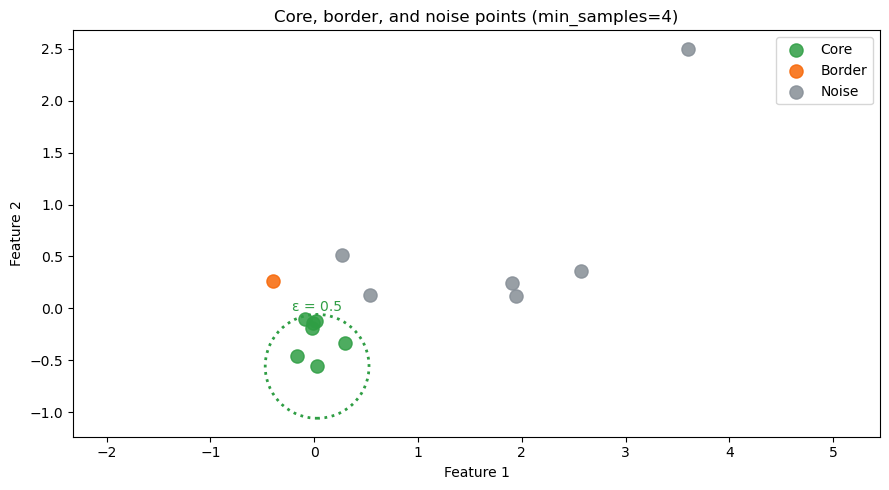

In [2]:
np.random.seed(3)
X_small = np.vstack([
    np.random.normal(loc=[0, 0], scale=0.3, size=(10, 2)),
    np.random.normal(loc=[2.2, 0.3], scale=0.25, size=(3, 2)),
    [[3.6, 2.5]],
])
eps, min_samples = 0.5, 4
db_small = DBSCAN(eps=eps, min_samples=min_samples).fit(X_small)
labels_small = db_small.labels_
core_mask = np.zeros(len(X_small), dtype=bool)
core_mask[db_small.core_sample_indices_] = True
point_type = np.where(core_mask, 'Core', np.where(labels_small == -1, 'Noise', 'Border'))
type_colors = {'Core': PALETTE['accent'], 'Border': PALETTE['secondary'], 'Noise': PALETTE['muted']}

fig, ax = plt.subplots(figsize=(9, 5))
for t in ['Core', 'Border', 'Noise']:
    mask = point_type == t
    if mask.any():
        ax.scatter(X_small[mask, 0], X_small[mask, 1], color=type_colors[t], s=90, alpha=0.85, label=t)

core_idx = db_small.core_sample_indices_[0]
cx, cy = X_small[core_idx]
circle = plt.Circle((cx, cy), eps, color=PALETTE['accent'], fill=False, linestyle=':', linewidth=2)
ax.add_patch(circle)
ax.annotate(f'ε = {eps}', xy=(cx, cy + eps), ha='center', va='bottom', color=PALETTE['accent'])

ax.set_title(f'Core, border, and noise points (min_samples={min_samples})')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
plt.tight_layout()
plt.show()


---
## What's happening?

The diagram above makes the DBSCAN decision rule concrete: a point is a core point only if there is a minimum density (MinPts within epsilon) around it. This local density test is what lets DBSCAN find clusters of arbitrary shape — it doesn't care about global geometry, only local density.

The code below shows DBSCAN's most powerful property at a larger scale: automatic K discovery. Unlike k-means, DBSCAN never asks for the number of clusters. It discovers them from the data's own density structure. Noise points are not failures — they are a feature. They are the points that genuinely don't belong to any cluster, and labeling them as noise rather than forcing them into a cluster is the honest answer.

In [3]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X_clean, _ = make_blobs(n_samples=250, centers=4, cluster_std=0.60, random_state=42)
noise = np.random.uniform(-8, 8, size=(50, 2))
X = np.vstack([X_clean, noise])
X_sc = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_sc)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)
print(f'Clusters found: {n_clusters}')
print(f'Noise points:   {n_noise}')
print(f'Cluster sizes:  {np.bincount(labels[labels >= 0])}')

Clusters found: 4
Noise points:   2
Cluster sizes:  [64 80 85 69]


---
## Real-world example: DBSCAN Finds Clusters and Outliers Simultaneously

K-means would force all 50 noise points into a cluster. DBSCAN correctly identifies them as noise. The scatter shows natural clusters in color and noise points in gray.

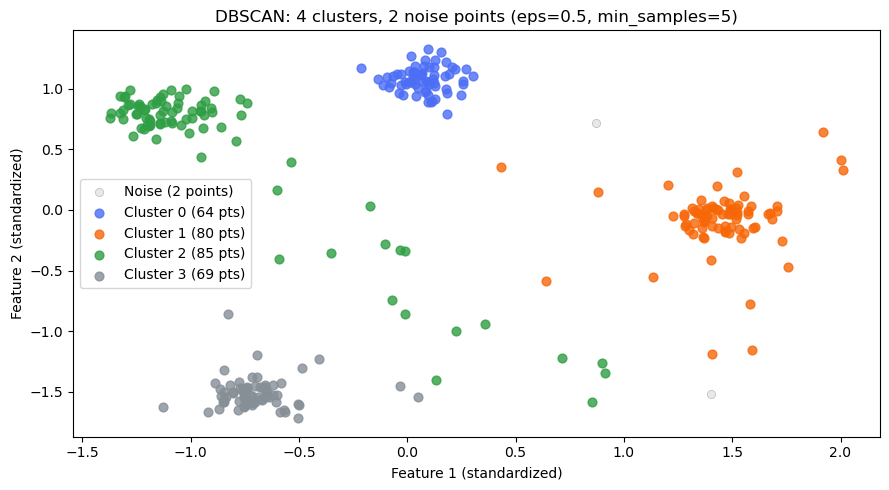

In [4]:
np.random.seed(42)
X_clean, _ = make_blobs(n_samples=250, centers=4, cluster_std=0.60, random_state=42)
noise = np.random.uniform(-8, 8, size=(50, 2))
X = np.vstack([X_clean, noise])
X_sc = StandardScaler().fit_transform(X)
labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_sc)

cluster_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['muted'], '#AE3EC9']
fig, ax = plt.subplots(figsize=(9, 5))

mask_noise = labels == -1
ax.scatter(X_sc[mask_noise, 0], X_sc[mask_noise, 1], color='lightgray', s=35, alpha=0.5,
           edgecolors='gray', linewidths=0.5, label=f'Noise ({mask_noise.sum()} points)')

n_clusters = len(set(labels)) - 1
for k in range(n_clusters):
    mask = labels == k
    ax.scatter(X_sc[mask, 0], X_sc[mask, 1], color=cluster_colors[k % len(cluster_colors)],
               s=40, alpha=0.8, label=f'Cluster {k} ({mask.sum()} pts)')

ax.set_title(f'DBSCAN: {n_clusters} clusters, {mask_noise.sum()} noise points (eps=0.5, min_samples=5)')
ax.set_xlabel('Feature 1 (standardized)')
ax.set_ylabel('Feature 2 (standardized)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Key hyperparameters

**`eps`** (required): The epsilon neighborhood radius. The most critical choice. A good heuristic: compute the k-nearest-neighbor distance for every point, sort them, and look for the elbow — that elbow value is a reasonable eps.

**`min_samples`** (default 5): Minimum points in an eps-neighborhood to be a core point. Higher values create denser, more conservative clusters and more noise points. Rule of thumb: min_samples ≥ dimensionality + 1.

sklearn docs: [sklearn.cluster.DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)

---
## Strengths and weaknesses

| Strength | Weakness |
|----------|----------|
| Discovers clusters of arbitrary shape | eps and min_samples are hard to tune |
| Automatically determines number of clusters | Struggles with varying density clusters |
| Identifies outliers natively (label = -1) | Sensitive to feature scale — scale first |
| No cluster center assumption | O(n²) without spatial indexing on high-dim data |
| Robust to outliers that don't pull centroids | Cannot handle datasets with very different densities |

---
## When to use it / When NOT to use it

| Use DBSCAN when... | Do NOT use DBSCAN when... |
|--------------------|---------------------------|
| Cluster shapes are non-convex | Clusters have very different densities |
| You don't know how many clusters exist | Dataset is very high-dimensional (distance degrades) |
| You want automatic outlier identification | You need to assign all points to a cluster |
| Data has clear density contrasts | eps and min_samples are impossible to tune meaningfully |
| Geographic or spatial clustering | Dataset is truly uniform (no density structure) |

---
## Key takeaway

> **DBSCAN finds clusters of any shape by looking at local density rather than distance to a center — and its automatic noise identification is not a bug, it is the most honest answer for points that genuinely don't belong.**

---
*Next up: 06_clustering_evaluation — where you learn three complementary metrics for choosing the right K and evaluating any clustering result*